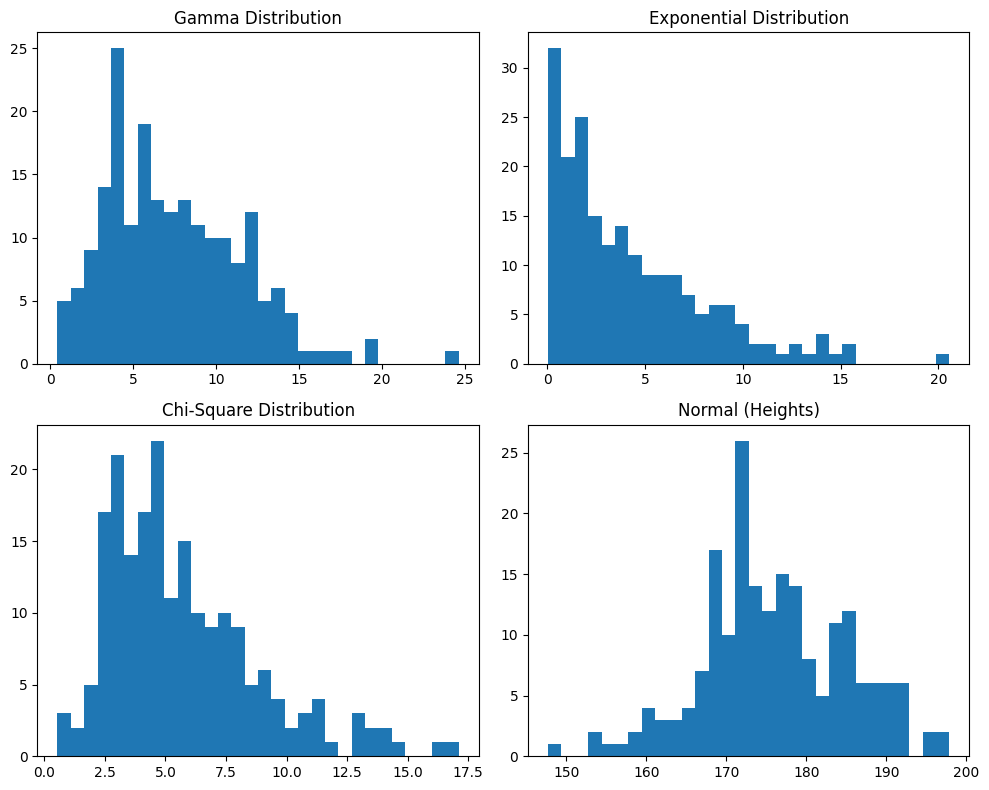

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
m = 200

heights = rng.normal(175, 10, size=(m, 1))
ages = rng.uniform(18, 60, size=(m, 1))
salaries_gamma = rng.gamma(shape=3.5, scale=2, size=(m, 1))
salaries_exp = rng.exponential(scale=4, size=(m, 1))
salaries_csq = rng.chisquare(df=6, size=(m, 1))

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].hist(salaries_gamma, bins=30)
axs[0, 0].set_title("Gamma Distribution")

axs[0, 1].hist(salaries_exp, bins=30)
axs[0, 1].set_title("Exponential Distribution")

axs[1, 0].hist(salaries_csq, bins=30)
axs[1, 0].set_title("Chi-Square Distribution")

axs[1, 1].hist(heights, bins=30)
axs[1, 1].set_title("Normal (Heights)")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([heights / 100, ages / 100])
X_b = add_dummy_feature(X)

y = salaries_gamma / 10
X_b, y

(array([[1.        , 1.65108786, 0.31006812],
        [1.        , 1.71322133, 0.25434458],
        [1.        , 1.87879253, 0.29257293],
        [1.        , 1.76939744, 0.53798884],
        [1.        , 1.84202309, 0.59751036],
        [1.        , 1.80771038, 0.33568318],
        [1.        , 1.68635364, 0.37393538],
        [1.        , 1.80419522, 0.32069519],
        [1.        , 1.71834045, 0.33348426],
        [1.        , 1.71776109, 0.46861287],
        [1.        , 1.75971673, 0.48883705],
        [1.        , 1.59740696, 0.31315579],
        [1.        , 1.86921661, 0.24090844],
        [1.        , 1.68289103, 0.47716092],
        [1.        , 1.85002694, 0.36454422],
        [1.        , 1.76363211, 0.56484402],
        [1.        , 1.90320331, 0.35192033],
        [1.        , 1.68400306, 0.1916403 ],
        [1.        , 1.71882051, 0.48497823],
        [1.        , 1.78377691, 0.59402839],
        [1.        , 1.52925289, 0.37587197],
        [1.        , 1.83279214, 0

## Batch Gradient Descent

The parameter update rule:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

Where:

| Symbol | Meaning |
|---|---|
| $\theta_j$ | Parameter (weight) for feature $j$ |
| $\alpha$ | Learning rate |
| $m$ | Number of training examples |
| $h_\theta(x^{(i)})$ | Predicted value for example $i$ |
| $y^{(i)}$ | Actual label for example $i$ |
| $x_j^{(i)}$ | Feature $j$ of example $i$ |

**In vector form:**

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

Where $X$ is the design matrix of shape $(m \times n)$ and $y$ is the label vector of shape $(m \times 1)$.

In [10]:
eta = 0.1
n_epochs = 3000
m = len(X_b)

rng = np.random.default_rng(123)

theta = rng.standard_normal((3, 1))

theta

array([[-0.98912135],
       [-0.36778665],
       [ 1.28792526]])

In [11]:
for epoch in range(n_epochs):
    gradients = 1 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

theta

array([[-0.45097387],
       [ 0.74095237],
       [-0.27200286]])

In [6]:
X_test = np.array([
    [1., 1.75, 0.35]
])

X_test @ theta

array([[0.75049178]])

## Stochastic Gradient Descent (SGD)

Same idea as Batch GD — but update theta using **one random example** at a time.


### What changed vs Batch GD

| | Batch GD | SGD |
|---|---|---|
| Gradient uses | all $m$ examples | 1 example at a time |
| Updates per epoch | 1 | $m$ |
| Path to minimum | smooth, stable | noisy, zigzag |
| Speed on big data | slow | fast, scalable |
| Local minima | can get stuck | noise helps escape |


$$\text{Batch: } \nabla = \frac{1}{m} X_b^T (X_b \theta - y)$$

$$\text{SGD: } \nabla = 2 \, x_i^T (x_i \theta - y_i)$$

**`theta = theta - eta * gradients`** — Identical update rule.

### The key intuition

SGD is noisier but much faster per epoch. That noise is actually useful — it helps the model escape local minima that Batch GD would get stuck in.

> In practice, most deep learning uses **Mini-batch GD** — the sweet spot between the two. Use a batch of 32–256 examples instead of 1 or all $m$.

In [ ]:
n_epochs = 1000
n_iterations = 100
t0, t1 = 500, 5000 

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((3, 1))  

for epoch in range(n_epochs):
    for iteration in range(n_iterations):

        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = xi.T @ (xi @ theta - yi)  
        eta = learning_schedule(epoch*n_iterations + iteration) 
        theta = theta - eta * gradients

theta

array([[-0.38465991],
       [ 0.70164076],
       [-0.28859971]])

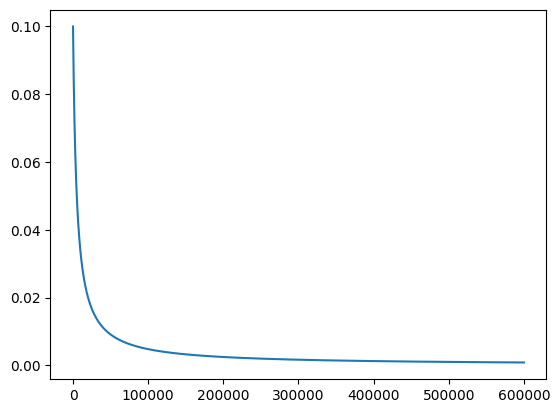

In [14]:
def learning_schedule(t):
    return 500 / (t + 5000)

etas = []

for epoch in range(n_epochs):
    for iteration in range(m):
        eta = learning_schedule(epoch * m + iteration)
        etas.append(eta)

plt.plot(etas)
plt.show()

In [15]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(
    max_iter=10000,
    penalty=None,
    eta0=0.1, 
    n_iter_no_change=1000,
    random_state=123
)

sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([-0.40712364]), array([ 0.70524189, -0.29707601]))

## Mini-batch Gradient Descent

The sweet spot between Batch GD and SGD.

| | Batch GD | SGD | Mini-batch GD |
|---|---|---|---|
| Data per update | all $m$ examples | 1 example | $k$ examples (e.g. 32) |
| Gradient quality | exact | very noisy | good enough |
| Speed | slow on big data | fast | fast + stable |
| Convergence | smooth | bouncy | smooth enough |

### What changed vs SGD

**`batch_size = 32`** — instead of 1 random example (SGD) or all $m$ examples
(Batch), take 32 at a time. 32, 64, 128, 256 are typical choices.

**`n_iterations = ceil(m / batch_size)`** — number of mini-batches per epoch.
If you have 1000 examples and batch size 32, that's $\lceil 1000/32 \rceil = 32$ iterations per epoch.

**Shuffle first, then slice** — unlike SGD which picks random indices,
mini-batch shuffles the whole dataset once per epoch then cuts it into chunks:
```python
shuffled_indices = rng.permutation(m)       # shuffle
X_b_shuffled = X_b[shuffled_indices]        # reorder X
y_shuffled = y[shuffled_indices]            # reorder y in same order

xi = X_b_shuffled[iteration*batch_size : (iteration+1)*batch_size]  # take chunk
```

**`1/batch_size`** — average the gradient over the batch, same as Batch GD used $\frac{1}{m}$.

### Why batch_size = 32?

No mathematical reason — it's a hardware thing. GPUs process data in
parallel, and powers of 2 (32, 64, 128, 256) align with how GPU memory
works. Larger batches → more stable gradients but more memory. Smaller
batches → noisier but faster updates.

### Learning rate still decays

Mini-batch is still stochastic (gradients are still noisy, just less so
than SGD), so the learning rate schedule is still needed for the same
reason — prevent bouncing around the minimum at the end.

$$\eta(t) = \frac{t_0}{t + t_1}$$

### The three variants — when to use which

- **Batch GD** — small datasets, when you need guaranteed smooth convergence
- **SGD** — very large datasets, online learning (data arriving in a stream)
- **Mini-batch GD** — everything else. default choice in deep learning.

In [20]:
n_epochs = 1000
minibatch_size = 20
n_batches_per_epoch = np.ceil(m / minibatch_size).astype('int')

rng = np.random.default_rng(123)
theta = rng.standard_normal((3, 1))

t0, t1 = 200, 1000

def learning_schedule(t):
    return t0 / (t + t1)

for epoch in range(n_epochs):

    shuffles_indices = rng.permutation(m)
    X_b_shiffled = X_b[shuffles_indices]
    y_shuffled = y[shuffles_indices]
    for iteration in range(n_batches_per_epoch):

        idx = iteration * minibatch_size
        xi = X_b_shiffled[idx:idx + minibatch_size]
        yi = y_shuffled[idx:idx + minibatch_size]
        gradients = 1 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients

theta

array([[-0.44787204],
       [ 0.74618227],
       [-0.29151636]])